# Laboratório da Gold

Este notebook é o rascunho do que virou a camada Gold. Ele existe porque **nada neste projeto vira código de produção sem o número conferido antes** — e conferir no notebook é mais barato que descobrir errado depois.

## O contexto, em três frases

O Brasil avalia todas as crianças no fim do 2º ano do ensino fundamental. Quem tira **743 pontos ou mais** na escala do Saeb é considerado alfabetizado — esse é o corte oficial. O **Indicador Criança Alfabetizada** é simplesmente o percentual de crianças que chegam lá, e cada município tem uma meta pactuada até 2030.

A camada Gold é a que transforma 3,8 milhões de linhas de aluno nas tabelas que respondem: *quantas crianças estão alfabetizadas, onde, e o quão longe da meta*.

## O que vamos fazer aqui

Quatro atos, nesta ordem — e a ordem importa:

| Ato | Pergunta | Por que vem nesta posição |
|---|---|---|
| **1** | Como se calcula a taxa? | Sem isso não há indicador nenhum |
| **2** | O que o dado permite responder? | Descobrir os limites **antes** de prometer análise que o dado não sustenta |
| **3** | O que o indicador esconde? | O número certo ainda pode enganar |
| **4** | Onde dá para mexer? | Só depois de entender tudo acima é que a conclusão vale |

Cada seção segue o mesmo ritmo: **pergunta → código → o que o número quer dizer**. Se você é júnior e está lendo isso para aprender, os trechos em *"Traduzindo"* explicam os conceitos de estatística que aparecem pelo caminho.

---

## Preparação

Duas coisas antes de começar: carregar o dado e configurar os gráficos.

Sobre as fontes — tudo vem da camada **Silver** (dado já limpo e padronizado):

| Tabela | O que é |
|---|---|
| `silver/alunos` | uma linha por aluno avaliado: nota, escola, município, rede |
| `silver/resultados/municipio` | as taxas **oficiais** já publicadas pelo INEP — nosso **gabarito** |
| `silver/metas` | a meta pactuada de cada município, UF e do Brasil |

Ter um gabarito muda tudo: dá para recalcular o indicador do zero e **conferir se bate**. É o que faz o Ato 1 inteiro.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SILVER = Path("../data/silver")
CORTE = 743  # a regra de negócio do projeto inteiro

pd.set_option("display.max_columns", 40)

alunos = pd.read_parquet(
    SILVER / "alunos",
    columns=["ano", "id_municipio", "id_escola", "id_aluno", "sigla_uf",
             "rede_nome", "proficiencia", "peso_aluno", "presente", "sem_nota"],
)
alunos["ano"] = alunos["ano"].astype("int64")

municipio = pd.read_parquet(SILVER / "resultados" / "municipio")   # o gabarito
metas = pd.read_parquet(SILVER / "metas")

print(f"alunos avaliados:      {len(alunos):>10,}")
print(f"gabarito (municipios): {len(municipio):>10,}")
print(f"metas:                 {len(metas):>10,}")

alunos avaliados:       3,867,589
gabarito (municipios):     23,995
metas:                     10,788


### A paleta dos gráficos

Não escolhi as cores por gosto. Elas vêm de uma paleta validada contra daltonismo (o par de cores mais parecido ainda tem separação folgada), e o resultado do teste manda **rotular o valor direto no gráfico** — por isso os números aparecem em cima das barras em vez de só na legenda. Cor sozinha nunca carrega a informação.

In [2]:
# paleta validada (o par adjacente mais crítico mantém separação sob daltonismo)
AZUL, AQUA, AMARELO = "#2a78d6", "#1baf7a", "#eda100"
VERMELHO, LARANJA, VERDE = "#d03b3b", "#fab219", "#0ca30c"   # crítico / atenção / bom
TINTA, TINTA_2, MUDO = "#0b0b0b", "#52514e", "#898781"
GRADE, FUNDO, EIXO = "#e1e0d9", "#fcfcfb", "#c3c2b7"

mpl.rcParams.update({
    "figure.figsize": (9, 4.4), "figure.facecolor": FUNDO, "figure.dpi": 110,
    "axes.facecolor": FUNDO, "axes.edgecolor": EIXO,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.axisbelow": True, "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "text.color": TINTA,
    "font.size": 10, "legend.frameon": False,
})


def titulos(ax, titulo, subtitulo):
    """Título + a frase que diz o que o leitor tem que enxergar no gráfico."""
    ax.set_title(titulo, pad=26)
    ax.text(0, 1.04, subtitulo, transform=ax.transAxes,
            color=TINTA_2, fontsize=9.5, va="bottom")


print("gráficos configurados")

gráficos configurados


---

## Antes do Ato 1: entendendo duas colunas

Duas colunas de `silver/alunos` decidem tudo o que vem depois. Vale analisar elas.

**`proficiencia`** — a nota do aluno na escala do Saeb. **Atenção:** não é uma nota de 0 a 100, nem de 0 a 1000. É uma escala própria, e o intervalo que ela ocupa de verdade é bem estreito. O primeiro gráfico mostra isso, e essa informação vai derrubar uma ideia inteira mais para a frente.

**`peso_aluno`** — o peso amostral.

> **Traduzindo: o que é peso amostral?**
> A avaliação não mede todas as crianças com a mesma intensidade. Se numa escola só metade da turma fez a prova, cada criança que fez precisa "valer por duas" para o resultado representar a turma inteira. Esse multiplicador é o `peso_aluno`.
> Consequência prática: a média correta **não** é somar as notas e dividir pelo número de alunos. É uma **média ponderada** — cada aluno entra com o seu peso. Descobrir isso é exatamente o assunto do Ato 1.

In [3]:
com_nota = alunos[alunos["presente"] & ~alunos["sem_nota"]].copy()
com_nota["alfa"] = (com_nota["proficiencia"] >= CORTE).astype(float)
com_nota["alfa_peso"] = com_nota["alfa"] * com_nota["peso_aluno"]

print("A escala de proficiência, na prática:")
print(f"  menor nota da base: {com_nota['proficiencia'].min():.1f}")
print(f"  maior nota da base: {com_nota['proficiencia'].max():.1f}")
print()
print("O peso amostral:")
print(f"  peso médio: {com_nota['peso_aluno'].mean():.2f}  "
      f"(um aluno com peso 2 'vale por dois' no cálculo)")
print(f"  peso mínimo: {com_nota['peso_aluno'].min():.2f} | "
      f"máximo: {com_nota['peso_aluno'].max():.2f}")
print()
print(f"  alunos avaliados:  {len(alunos):,}")
print(f"  ...que fizeram a prova e têm nota: {len(com_nota):,} "
      f"({100 * len(com_nota) / len(alunos):.1f}%)")

A escala de proficiência, na prática:
  menor nota da base: 578.5
  maior nota da base: 904.4

O peso amostral:
  peso médio: 1.15  (um aluno com peso 2 'vale por dois' no cálculo)
  peso mínimo: 0.10 | máximo: 142.55

  alunos avaliados:  3,867,589
  ...que fizeram a prova e têm nota: 3,354,661 (86.7%)


Para ver isso de uma vez, desenhei a distribuição das notas e marquei duas linhas: o corte oficial (743) e o corte de 500 que costuma ser usado como "crítico".

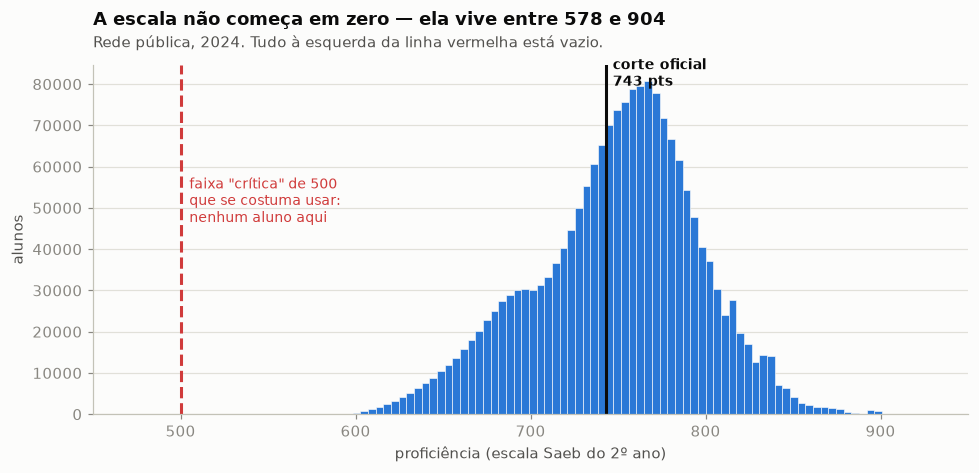

In [4]:
publica_24 = com_nota[(com_nota["ano"] == 2024)
                      & com_nota["rede_nome"].isin(["municipal", "estadual"])]

fig, ax = plt.subplots()
ax.hist(publica_24["proficiencia"], bins=70, color=AZUL, edgecolor=FUNDO, linewidth=0.4)
ax.grid(axis="y")

# as três linhas que importam
ax.axvline(CORTE, color=TINTA, linewidth=2)
ax.text(CORTE + 4, ax.get_ylim()[1] * 0.94, f"corte oficial\n{CORTE} pts",
        color=TINTA, fontsize=9, fontweight="bold")

ax.axvline(500, color=VERMELHO, linewidth=2, linestyle="--")
ax.text(505, ax.get_ylim()[1] * 0.55, 'faixa "crítica" de 500\nque se costuma usar:\nnenhum aluno aqui',
        color=VERMELHO, fontsize=9)

ax.set_xlim(450, 950)
ax.set_xlabel("proficiência (escala Saeb do 2º ano)")
ax.set_ylabel("alunos")
titulos(ax, "A escala não começa em zero — ela vive entre 578 e 904",
        "Rede pública, 2024. Tudo à esquerda da linha vermelha está vazio.")
plt.tight_layout()
plt.show()

Ao analisar esse gráfico, percebi que ele diz duas coisas:

1. **A escala é estreita.** Ninguém tira menos de 578. Um corte "crítico" em 500 pontos — que é comum ver, porque vem da escala do Saeb do 5º e 9º ano — classificaria **zero** crianças aqui. São réguas diferentes.
2. **A massa está espremida em volta do corte.** Tem muita gente logo abaixo dos 743. Isso vai virar um achado no Ato 4.

---

# Ato 1 — Como se calcula a taxa?

Parece simples: "percentual de alunos com nota ≥ 743, é só dividir". Mas há três armadilhas, e cada uma muda o número final. Como temos o gabarito oficial, dá para testar cada alternativa e ver qual bate.

## 1.1 — Média simples ou ponderada?

Duas formas de calcular a taxa de um município:

- **simples**: conta quantos alunos passaram dos 743 e divide pelo total. Cada aluno vale 1.
- **ponderada**: usa o `peso_aluno`. Cada aluno vale o seu peso.

Só uma delas reproduz o número oficial. Vamos descobrir qual, comparando **rede por rede** contra o gabarito.

> **Por que rede por rede?**
> O gabarito publica a taxa separada por rede (`municipal`, `estadual`, `publica`, `total`). Se eu misturar tudo e comparar com um número que é só da rede municipal, a diferença que eu encontrar não vai me dizer nada sobre ponderação — vai só refletir que estou comparando coisas diferentes.

In [5]:
def compara_com_gabarito(sub, rede_gabarito):
    """Calcula a taxa das duas formas e mede a distância até o número oficial."""
    g = sub.groupby(["ano", "id_municipio"]).agg(
        soma_alfa=("alfa", "sum"), n=("alfa", "size"),
        soma_alfa_peso=("alfa_peso", "sum"), soma_peso=("peso_aluno", "sum"),
    ).reset_index()
    g["simples"] = 100 * g["soma_alfa"] / g["n"]
    g["ponderada"] = 100 * g["soma_alfa_peso"] / g["soma_peso"]

    gab = municipio[municipio["rede_padronizada"] == rede_gabarito]
    c = g.merge(gab[["ano", "id_municipio", "taxa_alfabetizacao"]],
                on=["ano", "id_municipio"], how="inner")

    linhas = []
    for forma in ["simples", "ponderada"]:
        distancia = (c[forma] - c["taxa_alfabetizacao"]).abs()
        linhas.append({
            "rede": rede_gabarito, "forma": forma, "municipios": len(c),
            "erro_mediano_pp": round(distancia.median(), 4),
            "acerto_ate_0.05pp": round(100 * (distancia <= 0.05).mean(), 1),
        })
    return c, pd.DataFrame(linhas)


recortes = {
    "municipal": com_nota["rede_nome"] == "municipal",
    "estadual": com_nota["rede_nome"] == "estadual",
    "publica": com_nota["rede_nome"].isin(["municipal", "estadual"]),
    "total": com_nota["rede_nome"].notna(),
}

resumos = []
for rede, filtro in recortes.items():
    comparacao, resumo = compara_com_gabarito(com_nota[filtro], rede)
    resumos.append(resumo)
    if rede == "publica":
        comparacao_publica = comparacao   # guardo para olhar os outliers depois

placar = pd.concat(resumos, ignore_index=True)
placar

,rede,forma,municipios,erro_mediano_pp,acerto_ate_0.05pp
0,municipal,simples,10269,0.2707,23.3
1,municipal,ponderada,10269,0.0037,95.9
2,estadual,simples,2139,0.1626,41.1
3,estadual,ponderada,2139,0.0033,93.5
4,publica,simples,10387,0.2810,22.3
5,publica,ponderada,10387,0.0040,95.1
6,total,simples,398,0.0025,99.0
7,total,ponderada,398,0.0025,99.0


A tabela acima responde, mas é preciso procurar. Coloquei num gráfico a coluna que decide a questão: em quantos municípios cada forma de calcular acerta o número oficial.

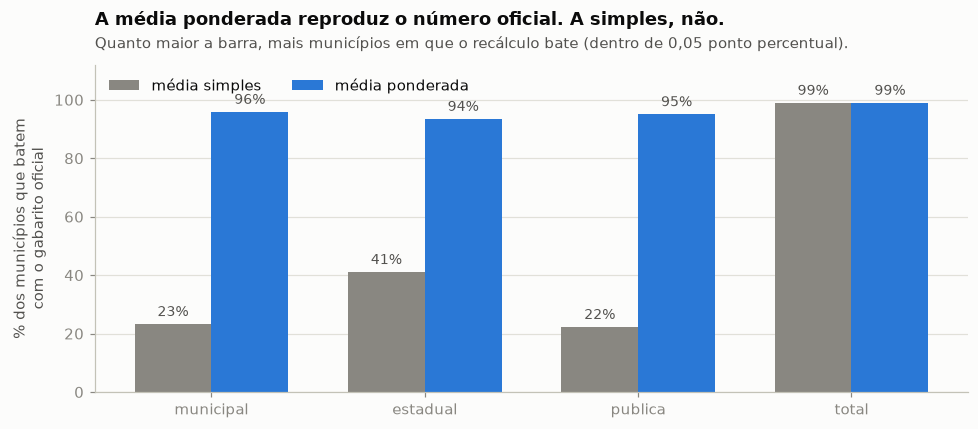

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
redes = ["municipal", "estadual", "publica", "total"]
x = np.arange(len(redes))
largura = 0.36

simples = [placar[(placar.rede == r) & (placar.forma == "simples")]["acerto_ate_0.05pp"].iloc[0] for r in redes]
ponderada = [placar[(placar.rede == r) & (placar.forma == "ponderada")]["acerto_ate_0.05pp"].iloc[0] for r in redes]

# a ponderada é o ponto do gráfico; a simples é contexto -> cinza
b1 = ax.bar(x - largura / 2, simples, largura, color=MUDO, label="média simples")
b2 = ax.bar(x + largura / 2, ponderada, largura, color=AZUL, label="média ponderada")

for barras in (b1, b2):
    ax.bar_label(barras, fmt="%.0f%%", padding=3, fontsize=9, color=TINTA_2)

ax.set_xticks(x, redes)
ax.set_ylim(0, 112)
ax.set_ylabel("% dos municípios que batem\ncom o gabarito oficial")
ax.grid(axis="y")
ax.legend(loc="upper left", ncols=2)
titulos(ax, "A média ponderada reproduz o número oficial. A simples, não.",
        "Quanto maior a barra, mais municípios em que o recálculo bate (dentro de 0,05 ponto percentual).")
plt.tight_layout()
plt.show()

**Decisão 1: a taxa oficial é a média ponderada pelo `peso_aluno`.** Não é sutil — nas redes municipal, estadual e pública ela acerta ~95% dos municípios, contra 20–40% da simples.

E a rede `total` explica o empate estranho: ela só existe para 398 municípios, e são justamente os municípios em que **todo aluno tem peso 1**. Sem correção amostral, as duas contas dão igual. Não é contradição — é o caso limite.

## 1.2 — Quem entra no denominador?

Nem todo aluno matriculado fez a prova. Então, dividir por quem?

- só os que **fizeram a prova e têm nota**;
- todos os **presentes**;
- **todos os avaliados**, inclusive quem faltou.

Testo os três contra o gabarito da rede pública.

In [7]:
def taxa_por_municipio(sub, nome):
    g = sub.groupby(["ano", "id_municipio"]).agg(
        soma_alfa_peso=("alfa_peso", "sum"), soma_peso=("peso_aluno", "sum")).reset_index()
    g[nome] = 100 * g["soma_alfa_peso"] / g["soma_peso"]
    return g[["ano", "id_municipio", nome]]


pub = alunos[alunos["rede_nome"].isin(["municipal", "estadual"])].copy()
pub["alfa"] = (pub["proficiencia"] >= CORTE).astype(float)
pub["alfa_peso"] = pub["alfa"] * pub["peso_aluno"]

gab_publica = municipio[municipio["rede_padronizada"] == "publica"]
teste = (taxa_por_municipio(pub[pub["presente"] & ~pub["sem_nota"]], "so_com_nota")
         .merge(taxa_por_municipio(pub[pub["presente"]], "todos_presentes"), on=["ano", "id_municipio"])
         .merge(taxa_por_municipio(pub, "todos_avaliados"), on=["ano", "id_municipio"])
         .merge(gab_publica[["ano", "id_municipio", "taxa_alfabetizacao"]],
                on=["ano", "id_municipio"], how="inner"))

for denominador in ["so_com_nota", "todos_presentes", "todos_avaliados"]:
    d = (teste[denominador] - teste["taxa_alfabetizacao"]).abs()
    print(f"{denominador:16s} erro mediano = {d.median():.4f}pp | "
          f"acerto até 0,05pp = {100 * (d <= 0.05).mean():.1f}%")

so_com_nota      erro mediano = 0.0040pp | acerto até 0,05pp = 95.1%
todos_presentes  erro mediano = 0.0040pp | acerto até 0,05pp = 95.1%
todos_avaliados  erro mediano = 0.0040pp | acerto até 0,05pp = 95.1%


**Os três dão idêntico** — e isso não é coincidência nem bug. O `peso_aluno` **só existe para quem tem nota**: quem faltou tem peso nulo, então já sai da conta sozinho, independente de eu filtrar ou não.

**Decisão 2: o denominador efetivo é "presentes com nota".** Mas cuidado com a armadilha: se os ausentes simplesmente somem da conta, a informação de que eles existem some junto. Por isso a taxa de participação vira **coluna própria** na Gold — e no Ato 3 a gente vê por que isso importa tanto.

### Antes de seguir: quem não bateu?

95% dos municípios batem. Sobrou 5% — e antes de seguir eu queria saber quem são.

In [8]:
comparacao_publica["erro"] = (comparacao_publica["ponderada"]
                              - comparacao_publica["taxa_alfabetizacao"]).abs()
fora = comparacao_publica[comparacao_publica["erro"] > 1]

print(f"municípios com erro acima de 1pp: {len(fora)} de {len(comparacao_publica):,} "
      f"({100 * len(fora) / len(comparacao_publica):.2f}%)")
print()
print("distribuídos por ano:")
print(fora.groupby("ano").size().rename("municipios").to_string())
print()
print("os 5 piores:")
fora.nlargest(5, "erro")[["ano", "id_municipio", "n", "ponderada",
                          "taxa_alfabetizacao", "erro"]].round(2)

municípios com erro acima de 1pp: 45 de 10,387 (0.43%)

distribuídos por ano:
ano
2023    32
2024    13

os 5 piores:


,ano,id_municipio,n,ponderada,taxa_alfabetizacao,erro
922,2023,2305100,71,55.61,91.67,36.06
2932,2023,3162450,75,45.92,64.64,18.72
106,2023,1304005,121,57.12,40.10,17.02
919,2023,2304905,118,83.11,99.15,16.04
10045,2024,5103908,64,51.60,66.10,14.50


São 45 municípios (0,43%), quase todos de **2023** — o ano da Pesquisa Alfabetiza Brasil, que teve desenho amostral diferente. Note a coluna `n`: são municípios com pouquíssimos alunos.

Não achei explicação fechada na fonte, então a decisão é pragmática e **documentada**: a Gold segue com o cálculo validado, e o check de qualidade acusa esses casos como *warning* a cada execução — avisa, mas não derruba a esteira. O que não pode é fingir que não existem.

## 1.3 — Qual meta vale?

A tabela de metas tem uma linha por ano de referência, e o planejamento suspeitava de revisões entre versões. Se a meta de 2024 mudou de valor entre a versão de 2023 e a de 2024, qual eu uso no confronto?

In [9]:
metas_mun = metas[metas["nivel"] == "municipio"]
piv = metas_mun.pivot_table(index="id_municipio", columns="ano",
                            values="meta_alfabetizacao_2024", aggfunc="first").dropna()
iguais = int((piv[2023] == piv[2024]).sum())
print(f"MUNICÍPIOS — nos dois snapshots: {len(piv):,}")
print(f"  meta 2024 idêntica: {iguais:,}  |  revisada: {len(piv) - iguais}")

metas_uf = metas[metas["nivel"] == "uf"]
piv_uf = metas_uf.pivot_table(index="sigla_uf", columns="ano",
                              values="meta_alfabetizacao_2024", aggfunc="first")
revisadas = piv_uf[piv_uf.nunique(axis=1) > 1]
print(f"\nUFs com meta 2024 revisada entre snapshots: {len(revisadas)} de {len(piv_uf)}")
revisadas.head(6)

MUNICÍPIOS — nos dois snapshots: 5,232
  meta 2024 idêntica: 5,232  |  revisada: 0

UFs com meta 2024 revisada entre snapshots: 22 de 24


ano,2023,2024,2025
sigla_uf,,,
AL,49.7,49.7,50.0
AM,56.8,56.8,57.0
AP,47.6,47.6,48.0
BA,43.4,43.4,43.0
ES,69.9,69.9,70.0
GO,68.9,68.9,69.0


**Zero revisões no nível municipal.** As mudanças só aparecem no snapshot de 2025, nos níveis Brasil/UF, e são arredondamentos (49,7 → 50,0). Como os resultados que a Gold confronta são de 2023 e 2024, a regra fica sem ambiguidade:

**Decisão 3: vale a meta vigente no ano do resultado.** E 2023 fica **sem meta** — as colunas de meta da fonte começam em 2024. Isso não é dado faltante: 2023 é a linha de base da política.

---

## ✅ O contrato do Ato 1

Isto é o que `src/03_gold/metricas_gold.py` implementa:

1. Taxa = **média ponderada pelo `peso_aluno`**, com a regra explícita `proficiencia >= 743`.
2. Denominador = **presentes com nota**; participação vira coluna própria.
3. Meta = a **vigente no ano do resultado**.
4. Um check compara o recálculo com o gabarito a cada execução, e os 45 outliers ficam documentados.

Se o Ato 1 fosse o fim, a Gold estaria "pronta". Os próximos três atos são sobre o que ainda estava faltando.

---

# Ato 2 — O que este dado permite responder?

Antes de prometer análise, é preciso saber o que o dado aguenta. É a parte do trabalho que menos aparece, e é a que evita entregar uma análise que não se sustenta.

## 2.1 — `id_escola` e `id_aluno` são códigos reais?

A pergunta parece técnica, mas ela decide o escopo do projeto inteiro.

**Se `id_escola` for o código INEP da escola**, dá para juntar com o **Censo Escolar** e trazer, de graça: se a escola é **urbana ou rural**, se tem biblioteca, água, internet. Isso destravaria toda a análise de desigualdade territorial.

Como testar: o código INEP tem 8 dígitos e **começa pelo código da UF** (11 a 53 — 11 é Rondônia, 35 é São Paulo, e assim por diante). Basta olhar os prefixos.

In [10]:
prefixos = sorted((alunos["id_escola"] // 1_000_000).unique())
print(f"prefixos encontrados em id_escola: {prefixos}")
print(f"faixa de valores: {alunos['id_escola'].min()} a {alunos['id_escola'].max()}")
print(f"escolas distintas: {alunos['id_escola'].nunique():,}")
print()
print("Um código INEP de verdade começaria com 11..53 (o código da UF). Nenhum começa.")

# se o id fosse estável, um aluno repetido entre anos estaria na mesma escola
repetidos = alunos[alunos.duplicated("id_aluno", keep=False)]
estabilidade = repetidos.groupby("id_aluno").agg(escolas=("id_escola", "nunique"))
print()
print(f"id_aluno que aparece em 2023 E em 2024: {len(estabilidade):,}")
print(f"  ...na mesma escola nos dois anos: "
      f"{100 * (estabilidade['escolas'] == 1).mean():.1f}%")

# mas dentro de um ano, o id se comporta?
por_ano = alunos.groupby(["ano", "id_escola"])["id_municipio"].nunique()
print()
print(f"escolas que aparecem em 2 municípios no MESMO ano: {(por_ano > 1).sum()}")

prefixos encontrados em id_escola: [np.int64(60)]
faixa de valores: 60000001 a 60042811
escolas distintas: 42,810

Um código INEP de verdade começaria com 11..53 (o código da UF). Nenhum começa.



id_aluno que aparece em 2023 E em 2024: 1,515,261
  ...na mesma escola nos dois anos: 0.1%



escolas que aparecem em 2 municípios no MESMO ano: 0


### São pseudônimos. E isso custa caro.

Os IDs vão de `60000001` a `60042811`, sequenciais, todos com prefixo `60` — que não é UF nenhuma. É um identificador **anonimizado**, criado pelo INEP para proteger a escola. Confirmei por fora: cruzando com as 222.589 escolas do Censo Escolar, a interseção é **zero**.

Pior: o pseudônimo **é sorteado de novo a cada ano**. Dos 1,5 milhão de `id_aluno` que aparecem nos dois anos, só **0,1%** caem na mesma escola. Ou seja: não é o mesmo aluno — é o mesmo número, dado a outra pessoa. E faz sentido, porque são turmas diferentes de 2º ano; nenhuma criança faz essa avaliação duas vezes.

**O que morre aqui:**

- ❌ **Urbana × rural** e infraestrutura da escola — dependiam do Censo Escolar.
- ❌ **Acompanhar o mesmo aluno no tempo.** Se alguém juntar `id_aluno` entre 2023 e 2024, vai receber um resultado que *parece* certo e é lixo. Não dá erro, não dá aviso — só mente. É o tipo de erro que passa despercebido e vai parar num relatório.

**O que sobrevive:**

- ✅ **`id_escola` funciona dentro de um ano.** Nenhuma escola aparece em dois municípios no mesmo ano. É chave limpa para agrupar — e é exatamente disso que o Ato 3 vai precisar.

> **O que eu tirei disso**
> Um ID com 8 dígitos e cara de código oficial não é, necessariamente, um código oficial. Confirmar custou 10 linhas. Não ter confirmado teria custado uma análise inteira.

### E "escola pública × privada"?

Comparar escola pública com privada parece o recorte mais óbvio de desigualdade. Antes de tentar, fui só contar quantos alunos existem em cada rede.

In [11]:
print("alunos por rede, em cada ano:")
print(alunos.groupby(["ano", "rede_nome"]).size().rename("alunos").to_string())
print()
print("redes que existem no gabarito oficial:")
print(sorted(municipio["rede_padronizada"].dropna().unique()))

alunos por rede, em cada ano:


ano   rede_nome
2023  estadual      155140
      municipal    1591889
2024  estadual      280258
      municipal    1840277
      privada           25

redes que existem no gabarito oficial:
['estadual', 'municipal', 'publica', 'total']


**A rede privada não existe nesta base.** São 25 alunos em 2024 e zero em 2023, contra 3,87 milhões de públicos — resíduo estatístico. E o gabarito oficial não traz **nenhuma** linha de rede privada ou federal.

Não é dado faltando: a pesquisa cobre a rede pública, por desenho. Qualquer comparação "pública × privada" é irrespondível aqui, e o certo é dizer isso, em vez de entregar uma comparação baseada em 25 crianças.

**Sobra o eixo que o dado sustenta: municipal × estadual.** Voltamos a ele no Ato 4.

---

# Ato 3 — O que o indicador esconde

O Ato 1 entregou um número certo. Este ato mostra por que um número certo ainda pode enganar.

## 3.1 — De quem é a variação: do município, da escola ou do aluno?

Toda a política pública — meta, ranking, repasse — é pactuada no **município**. A pergunta que ninguém faz: *é aí que a diferença está?*

Para responder, decomponho a variação da proficiência em três camadas encaixadas.

> **Traduzindo: o que é decompor a variância?**
> Variância é o quanto os valores se espalham em torno da média. Aqui, as notas variam por três motivos empilhados: (1) municípios são diferentes entre si, (2) dentro do mesmo município, escolas são diferentes, (3) dentro da mesma escola, alunos são diferentes.
> Decompor é medir **quanto cada motivo responde pelo espalhamento total**. Se o município explicasse 90%, o grão da política estaria certo. Se explicar pouco, a política está mirando na camada errada.

In [12]:
p24 = com_nota[(com_nota["ano"] == 2024)
               & com_nota["rede_nome"].isin(["municipal", "estadual"])].copy()

# a média do município e a média da escola de cada aluno
media_municipio = p24.groupby("id_municipio")["proficiencia"].transform("mean")
media_escola = p24.groupby("id_escola")["proficiencia"].transform("mean")

componentes = {
    "entre municípios": media_municipio.var(),
    "entre escolas, no mesmo município": (media_escola - media_municipio).var(),
    "entre alunos, na mesma escola": (p24["proficiencia"] - media_escola).var(),
}
decomposicao = pd.Series(componentes).to_frame("variancia")
decomposicao["participacao_%"] = (100 * decomposicao["variancia"]
                                  / decomposicao["variancia"].sum()).round(1)
decomposicao.round(1)

,variancia,participacao_%
entre municípios,353.3,16.0
"entre escolas, no mesmo município",199.3,9.0
"entre alunos, na mesma escola",1660.5,75.0


Os números acima já dizem tudo, mas numa barra só a proporção entre as três camadas fica bem mais visível.

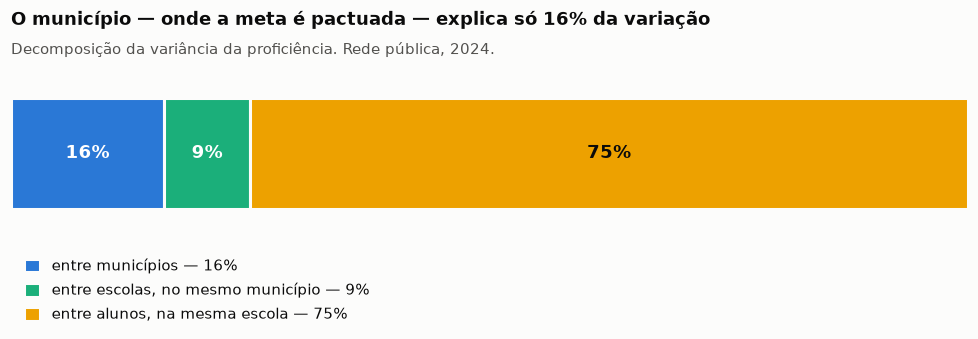

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.2))

cores = [AZUL, AQUA, AMARELO]
esquerda = 0
for (rotulo, linha), cor in zip(decomposicao.iterrows(), cores):
    parte = linha["participacao_%"]
    # a borda na cor do fundo cria o respiro entre os segmentos
    ax.barh(0, parte, left=esquerda, color=cor, edgecolor=FUNDO, linewidth=2,
            height=0.5, label=f"{rotulo} — {parte:.0f}%")
    ax.text(esquerda + parte / 2, 0, f"{parte:.0f}%", ha="center", va="center",
            color="white" if cor != AMARELO else TINTA, fontweight="bold", fontsize=12)
    esquerda += parte

ax.set_xlim(0, 100)
ax.set_ylim(-0.4, 0.4)
ax.axis("off")
# legenda em vez de rótulo embaixo de cada fatia: as fatias de 16% e 9% são
# estreitas demais e os textos colidiriam
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.02), fontsize=9.5,
          handlelength=1.1, handleheight=1.1, labelspacing=0.6)
titulos(ax, "O município — onde a meta é pactuada — explica só 16% da variação",
        "Decomposição da variância da proficiência. Rede pública, 2024.")
plt.tight_layout()
plt.show()

### Três quartos da diferença estão **dentro da mesma escola**.

Esse número me surpreendeu. Duas crianças na mesma sala, com a mesma professora, no mesmo bairro, diferem mais entre si do que dois municípios diferem entre si. O município — que é onde a meta é pactuada, onde o ranking é publicado, onde o repasse é decidido — responde por **16%**.

Isso **não** invalida o indicador municipal. Município é ente federado: ele assina meta, a escola não. Mas põe um teto na leitura: **dois municípios com a mesma taxa podem ser mundos diferentes por dentro**, e nenhuma tabela da Gold conseguia mostrar isso, porque a Gold parava no município.

É por isso que a camada `perfil_escola` passou a existir. A escola, que ninguém olhava, carrega 9% — mais da metade do que o município explica.

## 3.2 — Esse número é confiável?

A Gold publica um `atingiu_meta` (sim/não) para cada município. Mas um município com 12 alunos avaliados tem uma taxa que **balança dezenas de pontos por puro acaso**.

> **Traduzindo: o que é margem de erro (o `ic95`)?**
> Se você joga uma moeda 10 vezes e dá 7 caras, você não conclui que a moeda é viciada — 10 jogadas é pouco. Se der 700 caras em 1000 jogadas, aí sim.
> A **margem de erro** põe número nessa intuição: ela diz o quanto o resultado poderia ter variado por sorte. Escrevemos `taxa ± ic95`. Quanto **menos alunos**, **maior** a margem.
> A regra de ouro: **uma diferença menor que a margem de erro não é uma diferença.** É ruído.

In [14]:
def indicador_do_municipio(sub):
    g = sub.groupby("id_municipio").agg(
        alunos=("alfa", "size"),
        soma_alfa_peso=("alfa_peso", "sum"),
        soma_peso=("peso_aluno", "sum")).reset_index()
    g["taxa"] = 100 * g["soma_alfa_peso"] / g["soma_peso"]
    # margem de erro de uma proporção: quanto menor o n, maior a margem
    p = g["taxa"] / 100
    g["ic95"] = 1.96 * 100 * np.sqrt(p * (1 - p) / g["alunos"])
    return g


mun24 = indicador_do_municipio(p24)

print(f"margem de erro mediana: ±{mun24['ic95'].median():.1f}pp")
print()
for limite in [30, 50, 100]:
    sub = mun24[mun24["alunos"] < limite]
    print(f"  {len(sub):>4} municípios com menos de {limite:>3} alunos avaliados "
          f"→ margem média de ±{sub['ic95'].mean():.1f}pp")

margem de erro mediana: ±7.9pp

   544 municípios com menos de  30 alunos avaliados → margem média de ±17.6pp
  1259 municípios com menos de  50 alunos avaliados → margem média de ±15.1pp
  2593 municípios com menos de 100 alunos avaliados → margem média de ±12.5pp


Esse é o tipo de coisa que a gente entende melhor vendo. Coloquei cada município num gráfico: quantos alunos ele avaliou (eixo horizontal) contra a taxa que ele obteve (eixo vertical). Por cima, desenhei a faixa dentro da qual a taxa pode cair **só por acaso**, dado o tamanho da amostra.

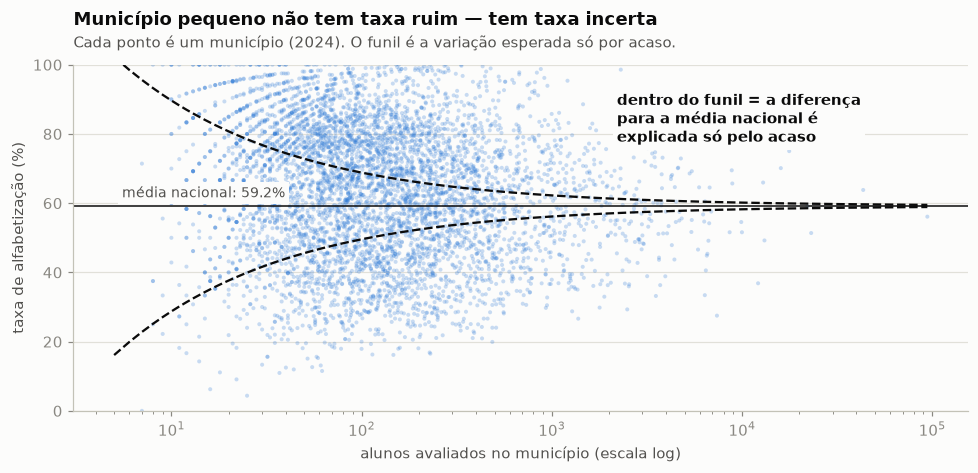

In [15]:
fig, ax = plt.subplots()

ax.scatter(mun24["alunos"], mun24["taxa"], s=7, color=AZUL, alpha=0.25,
           edgecolors="none")

# o "funil": a faixa em que a taxa cai por puro acaso, dado o tamanho da amostra
media_nacional = 100 * p24["alfa_peso"].sum() / p24["peso_aluno"].sum()
n = np.arange(5, mun24["alunos"].max())
p = media_nacional / 100
margem = 1.96 * 100 * np.sqrt(p * (1 - p) / n)
ax.plot(n, media_nacional + margem, color=TINTA, linewidth=1.5, linestyle="--")
ax.plot(n, media_nacional - margem, color=TINTA, linewidth=1.5, linestyle="--")
ax.axhline(media_nacional, color=TINTA, linewidth=1)

# caixa na cor do fundo para o texto não brigar com os pontos
caixa = dict(facecolor=FUNDO, edgecolor="none", pad=2.5)
ax.text(2200, 92, "dentro do funil = a diferença\npara a média nacional é\nexplicada só pelo acaso",
        color=TINTA, fontsize=9.5, fontweight="bold", va="top", bbox=caixa)
ax.text(5.5, media_nacional + 2.5, f"média nacional: {media_nacional:.1f}%",
        color=TINTA_2, fontsize=9, bbox=caixa)

ax.set_xscale("log")
ax.set_xlabel("alunos avaliados no município (escala log)")
ax.set_ylabel("taxa de alfabetização (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y")
titulos(ax, "Município pequeno não tem taxa ruim — tem taxa incerta",
        "Cada ponto é um município (2024). O funil é a variação esperada só por acaso.")
plt.tight_layout()
plt.show()

Esse formato se chama **gráfico de funil**, e foi o que mais me ajudou a entender o dado.

À direita, onde há milhares de alunos, os pontos são uma linha fina: a taxa é medida com precisão. À esquerda, onde há dezenas de alunos, os pontos **explodem de 0% a 100%**. Aqueles municípios lá em cima, com 100% de alfabetização, e os lá embaixo, com 0%? Não são os melhores e os piores do Brasil. **São os menores.**

Um ranking de municípios por taxa, feito sem olhar o tamanho, teria o topo e o fundo preenchidos por ruído. É um erro que aparece em reportagem, em dashboard e em política pública.

E o custo disso na tabela que já existia:

In [16]:
metas_2024 = metas[(metas["nivel"] == "municipio") & (metas["ano"] == 2024)]
metas_2024 = metas_2024[["id_municipio", "meta_alfabetizacao_2024"]].dropna()

confronto = mun24.merge(metas_2024, on="id_municipio", how="inner")
confronto["gap"] = confronto["taxa"] - confronto["meta_alfabetizacao_2024"]

# a diferença para a meta é maior que a própria margem de erro?
confronto["conclusivo"] = confronto["gap"].abs() >= confronto["ic95"]

print(f"municípios com meta pactuada em 2024: {len(confronto):,}")
print()
print(f"  gap MENOR que a própria margem de erro: "
      f"{(~confronto['conclusivo']).sum():,} "
      f"({100 * (~confronto['conclusivo']).mean():.1f}%)")
print("  ↑ nesses, dizer 'atingiu' ou 'não atingiu' é reportar ruído como fato")

municípios com meta pactuada em 2024: 5,232

  gap MENOR que a própria margem de erro: 2,294 (43.8%)
  ↑ nesses, dizer 'atingiu' ou 'não atingiu' é reportar ruído como fato


**Em 44% dos municípios com meta, o `atingiu_meta` não significa nada.** A diferença entre o resultado e a meta é menor que a incerteza do próprio resultado.

Esse booleano já estava no ar, sendo consumido. Não era uma tabela faltando — era uma **tabela errando**. Por isso a Gold ganhou a coluna `situacao_meta`, que tem um terceiro estado: `indistinguivel`.

## 3.3 — E quem faltou na prova?

12% dos alunos matriculados não fizeram a prova. Como eles não têm nota, saem do denominador (Decisão 2). Se as faltas fossem aleatórias, tudo bem. **Serão?**

In [17]:
todos_24 = alunos[(alunos["ano"] == 2024)
                  & alunos["rede_nome"].isin(["municipal", "estadual"])]

participacao = todos_24.groupby("id_municipio").agg(
    avaliados=("presente", "size"), presentes=("presente", "sum"))
participacao["taxa_participacao"] = 100 * participacao["presentes"] / participacao["avaliados"]
participacao = participacao.join(mun24.set_index("id_municipio")["taxa"])

faltaram = int((~todos_24["presente"]).sum())
print(f"alunos que faltaram: {faltaram:,} de {len(todos_24):,} "
      f"({100 * (~todos_24['presente']).mean():.1f}%)")
print()
print("A falta é aleatória?")
print(f"  correlação entre participação e taxa: "
      f"{participacao['taxa_participacao'].corr(participacao['taxa']):+.2f}")
print("  ↑ positiva: onde falta mais gente, o desempenho de quem ficou também é pior")
print()

# e se TODOS os faltantes fossem reprovados? e se todos fossem aprovados?
peso_medio = p24["peso_aluno"].mean()
peso_faltante = faltaram * peso_medio
soma_alfa = p24["alfa_peso"].sum()
denominador = p24["peso_aluno"].sum() + peso_faltante

pior = 100 * soma_alfa / denominador
melhor = 100 * (soma_alfa + peso_faltante) / denominador
print(f"taxa publicada:                              {media_nacional:.1f}%")
print(f"se TODOS os faltantes NÃO fossem alfabetizados: {pior:.1f}%")
print(f"se TODOS os faltantes fossem alfabetizados:     {melhor:.1f}%")
print(f"→ a verdade está em algum ponto de um intervalo de {melhor - pior:.1f}pp")

alunos que faltaram: 267,771 de 2,120,535 (12.6%)

A falta é aleatória?
  correlação entre participação e taxa: +0.29
  ↑ positiva: onde falta mais gente, o desempenho de quem ficou também é pior

taxa publicada:                              59.2%
se TODOS os faltantes NÃO fossem alfabetizados: 51.7%
se TODOS os faltantes fossem alfabetizados:     64.4%
→ a verdade está em algum ponto de um intervalo de 12.6pp


**A falta não é aleatória.** A correlação é positiva: **falta mais gente justamente onde o desempenho é pior**. Ou seja, quem não fez a prova tende a ser quem puxaria a média para baixo — e a taxa publicada sai **inflada**.

Os dois extremos delimitam o que o dado permite afirmar: entre **51,7%** e **64,4%**. Os 59,2% publicados são uma escolha metodológica razoável dentro desse intervalo, não um fato exato.

Não é para trocar a taxa oficial — é para publicar a participação **do lado dela**, e marcar os municípios onde ela é baixa demais para o número significar algo.

## 3.4 — Onde estão as crianças?

Uma coisa que percentual **não** mostra: quantas crianças são.

Um município de 12 alunos com 40% de alfabetização aparece como "pior" que uma capital com 60%. Mas o primeiro tem 7 crianças fora da alfabetização, e a capital tem dezenas de milhares. Se você é o ministro e tem que escolher onde colocar o programa, qual dos dois?

In [18]:
p24 = p24.copy()
p24["criancas_fora"] = (1 - p24["alfa"]) * p24["peso_aluno"]

deficit = (p24.groupby("id_municipio")["criancas_fora"].sum()
           .sort_values(ascending=False).to_frame())
deficit["acumulado_%"] = 100 * deficit["criancas_fora"].cumsum() / deficit["criancas_fora"].sum()

print(f"total estimado de crianças não alfabetizadas: "
      f"{deficit['criancas_fora'].sum():,.0f}")
print()
for alvo in [25, 50]:
    n = int((deficit["acumulado_%"] <= alvo).sum()) + 1
    print(f"  {alvo}% dessas crianças estão em apenas {n} municípios "
          f"({100 * n / len(deficit):.1f}% dos municípios do país)")

# o ranking da pior taxa e o ranking do maior volume apontam para os mesmos lugares?
piores_taxa = set(mun24[mun24["alunos"] >= 50].nsmallest(50, "taxa")["id_municipio"])
maior_deficit = set(deficit.head(50).index)
print()
print(f"municípios que estão nas DUAS listas "
      f"(50 piores taxas × 50 maiores volumes): {len(piores_taxa & maior_deficit)}")

total estimado de crianças não alfabetizadas: 860,541

  25% dessas crianças estão em apenas 34 municípios (0.6% dos municípios do país)
  50% dessas crianças estão em apenas 195 municípios (3.5% dos municípios do país)

municípios que estão nas DUAS listas (50 piores taxas × 50 maiores volumes): 0


Para ver o tamanho dessa concentração, ordenei os municípios do maior déficit para o menor e fui somando as crianças. Se o problema estivesse espalhado por igual pelo país, a curva seria a diagonal.

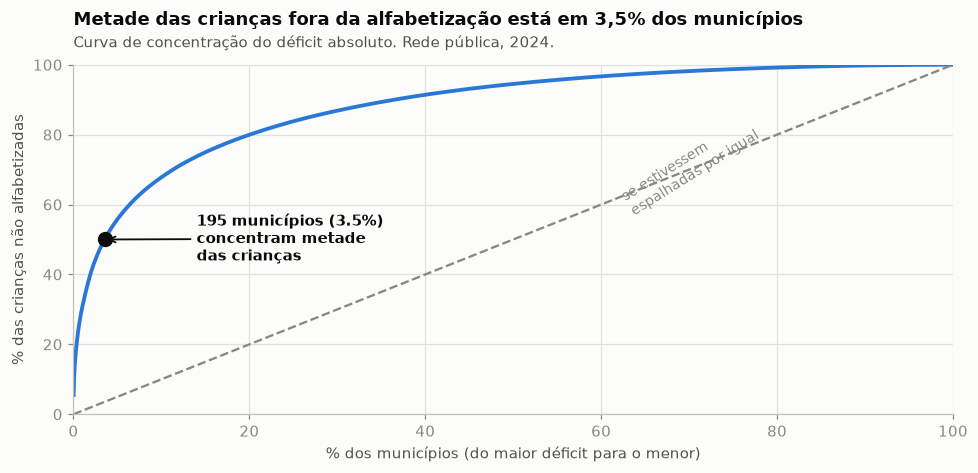

In [19]:
fig, ax = plt.subplots()

x = 100 * np.arange(1, len(deficit) + 1) / len(deficit)
ax.plot(x, deficit["acumulado_%"], color=AZUL, linewidth=2.5)
ax.plot([0, 100], [0, 100], color=MUDO, linewidth=1.5, linestyle="--")
ax.text(62, 57, "se estivessem\nespalhadas por igual", color=MUDO, fontsize=9, rotation=32)

# marca o ponto dos 50%
n50 = int((deficit["acumulado_%"] <= 50).sum()) + 1
x50 = 100 * n50 / len(deficit)
ax.plot([x50], [50], marker="o", markersize=9, color=TINTA, zorder=5)
ax.annotate(f"{n50} municípios ({x50:.1f}%)\nconcentram metade\ndas crianças",
            xy=(x50, 50), xytext=(14, 44), fontsize=9.5, color=TINTA, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=TINTA, linewidth=1.2))

ax.set_xlabel("% dos municípios (do maior déficit para o menor)")
ax.set_ylabel("% das crianças não alfabetizadas")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid()
titulos(ax, "Metade das crianças fora da alfabetização está em 3,5% dos municípios",
        "Curva de concentração do déficit absoluto. Rede pública, 2024.")
plt.tight_layout()
plt.show()

E o detalhe que fecha o argumento: entre "os 50 municípios com pior taxa" e "os 50 com mais crianças fora", a sobreposição é **zero**.

Não são dois mapas parecidos. **São dois mapas diferentes.** Priorizar por taxa aponta para municípios pequenos; priorizar por volume aponta para as capitais. As duas leituras são legítimas — mas a Gold só permitia uma. Por isso entrou a coluna `criancas_nao_alfabetizadas`.

> A análise de evolução 2023 → 2024 (a "regressão à média", que mostra por que a Gold não publica ranking de quem mais avançou) saiu deste laboratório: como ela parte da Gold já materializada, vive no notebook companheiro [`analise_gold.ipynb`](analise_gold.ipynb).

---

# Ato 4 — Onde dá para mexer

Os atos anteriores foram sobre entender e desconfiar. Este é sobre o que fazer.

## 4.1 — A régua escondida: os 9 níveis do INEP

O gabarito tem 9 colunas — `proporcao_aluno_nivel_0` até `_8` — com o percentual de alunos em cada nível da escala oficial. Mas **o dicionário da fonte não diz onde cada nível começa e termina**. Vieram as proporções sem a régua.

Dá para descobrir a régua. Se eu sei que 2,17% dos alunos estão no nível 0, então o corte do nível 0 é a nota que deixa exatamente 2,17% dos alunos abaixo dela. Isso se chama **quantil**, e é uma linha de código.

In [20]:
colunas_oficiais = [f"proporcao_aluno_nivel_{i}" for i in range(9)]
gab24 = municipio[(municipio["rede_padronizada"] == "publica") & (municipio["ano"] == 2024)]

# a proporção acumulada oficial: 8 fronteiras separam 9 níveis
acumulado = gab24[colunas_oficiais].mean().cumsum().values[:-1]
print("proporção acumulada oficial em cada fronteira (%):")
print(np.round(acumulado, 1))

# em que nota cada uma dessas fronteiras cai?
ordem = np.argsort(p24["proficiencia"].values)
notas = p24["proficiencia"].values[ordem]
peso_acumulado = 100 * np.cumsum(p24["peso_aluno"].values[ordem]) / p24["peso_aluno"].sum()

cortes_descobertos = np.interp(acumulado, peso_acumulado, notas)
print()
print("notas correspondentes (os cortes que estávamos procurando):")
print(np.round(cortes_descobertos, 1))

proporção acumulada oficial em cada fronteira (%):
[ 2.2  6.3 13.7 24.7 42.7 67.1 86.1 95.3]

notas correspondentes (os cortes que estávamos procurando):
[644.8 668.7 692.1 719.1 745.2 770.8 795.8 821.5]


`[645, 669, 692, 719, 745, 771, 796, 822]`. Está na cara: é uma grade **de 25 em 25 pontos, a partir de 650**. O resto é ruído da aproximação.

Hipótese: os cortes são **650, 675, 700, 725, 750, 775, 800, 825**. Agora o teste de verdade — se a régua estiver certa, ela tem que reproduzir as colunas oficiais.

In [21]:
CORTES_NIVEL = [650, 675, 700, 725, 750, 775, 800, 825]
p24["nivel"] = pd.cut(p24["proficiencia"], [-np.inf, *CORTES_NIVEL, np.inf],
                      labels=range(9), right=False)

# recalculo a distribuição, município a município
peso_por_nivel = (p24.groupby(["id_municipio", "nivel"], observed=True)["peso_aluno"]
                  .sum().unstack(fill_value=0))
recalculado = 100 * peso_por_nivel.div(peso_por_nivel.sum(axis=1), axis=0)
recalculado.columns = [f"recalc_{i}" for i in recalculado.columns]

conferencia = recalculado.join(gab24.set_index("id_municipio")[colunas_oficiais], how="inner")
erros = pd.concat([(conferencia[f"recalc_{i}"] - conferencia[colunas_oficiais[i]]).abs()
                   for i in range(9)])

print(f"municípios conferidos: {len(conferencia):,}  (× 9 níveis cada)")
print(f"erro mediano: {erros.median():.4f} ponto percentual")
print(f"erro no percentil 95: {erros.quantile(0.95):.3f}pp")

municípios conferidos: 5,516  (× 9 níveis cada)
erro mediano: 0.0028 ponto percentual
erro no percentil 95: 0.016pp


O número já diz que bateu, mas eu queria ver. Coloquei lado a lado a distribuição que o INEP publica e a que recalculei com a régua descoberta.

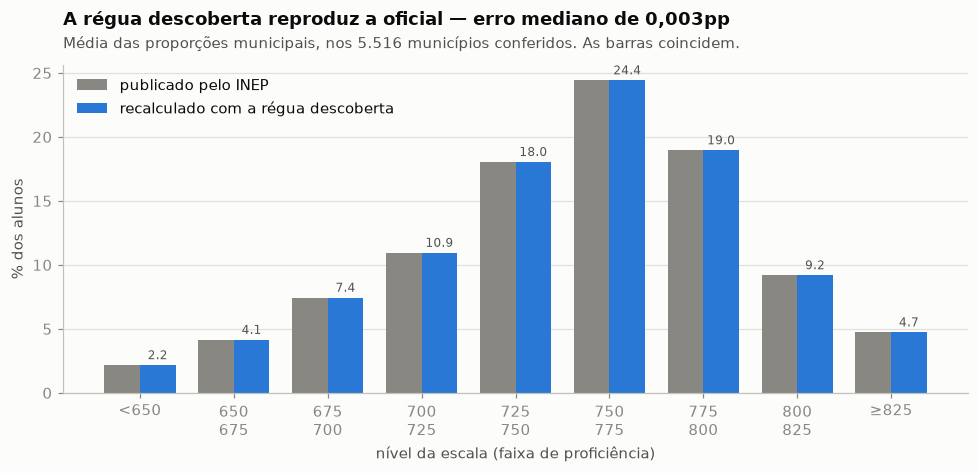

In [22]:
fig, ax = plt.subplots()

# comparo no MESMO grão dos dois lados: a média das proporções municipais, nos
# mesmos municípios. (Comparar a média municipal do INEP com a proporção nacional
# ponderada seria comparar coisas diferentes — e daria uma diferença falsa.)
oficial = [conferencia[coluna].mean() for coluna in colunas_oficiais]
nosso = [conferencia[f"recalc_{i}"].mean() for i in range(9)]

x = np.arange(9)
largura = 0.38
ax.bar(x - largura / 2, oficial, largura, color=MUDO, label="publicado pelo INEP")
b2 = ax.bar(x + largura / 2, nosso, largura, color=AZUL,
            label="recalculado com a régua descoberta")
ax.bar_label(b2, fmt="%.1f", padding=2, fontsize=8, color=TINTA_2)

faixas = ["<650", "650\n675", "675\n700", "700\n725", "725\n750",
          "750\n775", "775\n800", "800\n825", "≥825"]
ax.set_xticks(x, faixas)
ax.set_xlabel("nível da escala (faixa de proficiência)")
ax.set_ylabel("% dos alunos")
ax.grid(axis="y")
ax.legend(loc="upper left")
titulos(ax, "A régua descoberta reproduz a oficial — erro mediano de 0,003pp",
        "Média das proporções municipais, nos 5.516 municípios conferidos. As barras coincidem.")
plt.tight_layout()
plt.show()

**Erro mediano de 0,003 ponto percentual**, em 5.516 municípios × 9 níveis. A régua está certa.

Isso vale mais do que parece: agora a Gold pode publicar a distribuição por nível **e ainda validar contra o gabarito oficial a cada execução**. Uma coluna derivada que se auto-confere. É o melhor check da camada.

⚠️ Um detalhe para não esquecer: o corte de alfabetização (743) cai **dentro do nível 4** (725–750). As duas réguas não se encaixam, e o dicionário de dados avisa isso. Não tente converter uma na outra.

## 4.2 — Quantas crianças estão quase lá?

Voltando ao primeiro gráfico: tem muita gente empilhada logo abaixo dos 743. Quanta, exatamente? E o que aconteceria se elas cruzassem?

In [23]:
peso = p24["peso_aluno"]
prof = p24["proficiencia"]
base = 100 * (peso * (prof >= CORTE)).sum() / peso.sum()

faixas = {
    "crítico (< 700)": prof < 700,
    "atenção (700–742)": (prof >= 700) & (prof < CORTE),
    "alfabetizado (≥ 743)": prof >= CORTE,
    "── a faixa '< 500' que se costuma usar": prof < 500,
}
for nome, mascara in faixas.items():
    print(f"  {nome:40s} {100 * peso[mascara].sum() / peso.sum():5.1f}%  "
          f"({int(mascara.sum()):>9,} alunos)")

print()
print(f"taxa hoje: {base:.1f}%")
ganhos = {}
for margem in [5, 10, 15, 20]:
    nova = 100 * (peso * (prof >= CORTE - margem)).sum() / peso.sum()
    ganhos[margem] = nova
    print(f"  se todos a até {margem:>2} pontos do corte cruzassem: "
          f"{nova:.1f}%  ({nova - base:+.1f}pp)")

  crítico (< 700)                           16.7%  (  302,967 alunos)
  atenção (700–742)                         24.1%  (  441,758 alunos)
  alfabetizado (≥ 743)                      59.2%  (1,107,103 alunos)
  ── a faixa '< 500' que se costuma usar     0.0%  (        0 alunos)

taxa hoje: 59.2%
  se todos a até  5 pontos do corte cruzassem: 63.3%  (+4.1pp)


  se todos a até 10 pontos do corte cruzassem: 67.0%  (+7.8pp)
  se todos a até 15 pontos do corte cruzassem: 70.3%  (+11.1pp)
  se todos a até 20 pontos do corte cruzassem: 73.3%  (+14.1pp)


Passei os cenários para um gráfico: a taxa de hoje e o que ela seria se as crianças logo abaixo do corte cruzassem a linha.

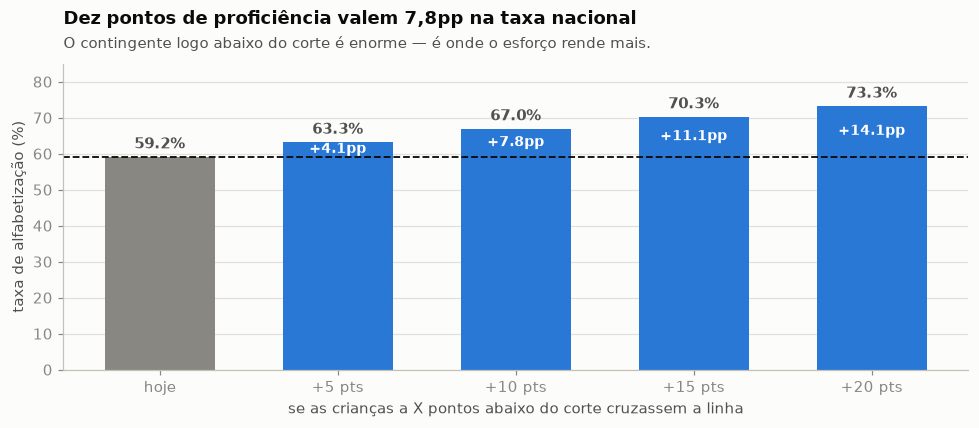

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))

rotulos = ["hoje"] + [f"+{m} pts" for m in ganhos]
valores = [base] + list(ganhos.values())
cores = [MUDO] + [AZUL] * len(ganhos)

barras = ax.bar(rotulos, valores, color=cores, width=0.62)
ax.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=10,
             fontweight="bold", color=TINTA_2)

# quanto cada passo adiciona
for i, (margem, valor) in enumerate(ganhos.items(), start=1):
    ax.annotate(f"{valor - base:+.1f}pp", xy=(i, base + (valor - base) / 2),
                ha="center", va="center", fontsize=9, color="white", fontweight="bold")

ax.axhline(base, color=TINTA, linewidth=1.2, linestyle="--")
ax.set_ylim(0, 85)
ax.set_ylabel("taxa de alfabetização (%)")
ax.set_xlabel("se as crianças a X pontos abaixo do corte cruzassem a linha")
ax.grid(axis="y")
titulos(ax, "Dez pontos de proficiência valem 7,8pp na taxa nacional",
        "O contingente logo abaixo do corte é enorme — é onde o esforço rende mais.")
plt.tight_layout()
plt.show()

**+7,8 pontos percentuais** se todas as crianças a 10 pontos do corte cruzassem — a taxa nacional saltaria de 59,2% para 67,0%. E "10 pontos" nessa escala é pouco: é a diferença entre ler travando e ler corrido.

Esse é o tipo de número que muda decisão. Nenhuma tabela da Gold respondia "onde o esforço rende mais" — agora a coluna `pct_quase_la` responde.

## 4.3 — As escolas que vencem o próprio contexto

O Ato 3 mostrou que a escola carrega 9% da variação, e o Ato 2 liberou o `id_escola` para uso dentro do ano. Junte as duas coisas.

A pergunta: **quanto uma escola se afasta do próprio município?** Comparar uma escola do interior do Piauí com uma de Curitiba não diz nada — contextos diferentes. Mas comparar uma escola com **as outras escolas da mesma cidade** controla praticamente tudo: mesmo contexto socioeconômico, mesma prefeitura, mesma rede.

In [25]:
escolas = p24.groupby("id_escola").agg(
    id_municipio=("id_municipio", "first"),
    alunos=("alfa", "size"),
    soma_alfa_peso=("alfa_peso", "sum"),
    soma_peso=("peso_aluno", "sum"))
escolas["taxa"] = 100 * escolas["soma_alfa_peso"] / escolas["soma_peso"]

escolas = escolas.join(mun24.set_index("id_municipio")["taxa"].rename("taxa_municipio"),
                       on="id_municipio")
escolas["residuo"] = escolas["taxa"] - escolas["taxa_municipio"]

# escola pequena tem resíduo ruidoso — mesmo problema do funil (3.2)
robustas = escolas[escolas["alunos"] >= 20]
print(f"escolas em 2024: {len(escolas):,} | com pelo menos 20 alunos: {len(robustas):,}")
print()
print(f"  {int((robustas['residuo'] > 20).sum()):,} escolas estão 20pp ACIMA do próprio município")
print(f"  {int((robustas['residuo'] < -20).sum()):,} escolas estão 20pp ABAIXO")

escolas em 2024: 42,327 | com pelo menos 20 alunos: 31,468



  2,085 escolas estão 20pp ACIMA do próprio município
  2,008 escolas estão 20pp ABAIXO


Desenhei a distribuição dos resíduos. O centro são as escolas que vão igual ao seu município; o que interessa são as caudas — as escolas que se descolam do próprio contexto, para cima ou para baixo.

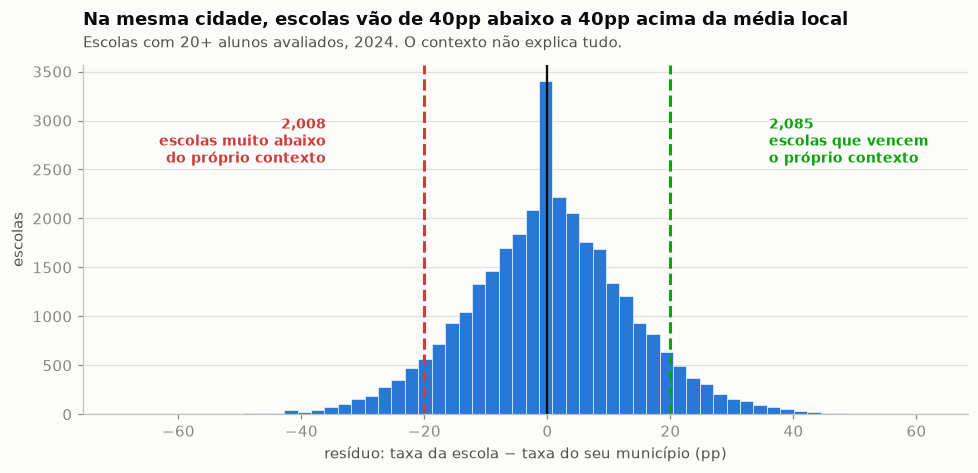

In [26]:
fig, ax = plt.subplots()

ax.hist(robustas["residuo"], bins=60, color=AZUL, edgecolor=FUNDO, linewidth=0.4)
ax.axvline(0, color=TINTA, linewidth=1.5)

topo = ax.get_ylim()[1]
for limite, cor, texto, dx in [(20, VERDE, "escolas que vencem\no próprio contexto", 4),
                               (-20, VERMELHO, "escolas muito abaixo\ndo próprio contexto", -4)]:
    ax.axvline(limite, color=cor, linewidth=2, linestyle="--")
    quantas = int((robustas["residuo"] > 20).sum() if limite > 0
                  else (robustas["residuo"] < -20).sum())
    ax.text(limite + dx * 4, topo * 0.72, f"{quantas:,}\n{texto}", color=cor, fontsize=9,
            fontweight="bold", ha="left" if limite > 0 else "right")

ax.set_xlabel("resíduo: taxa da escola − taxa do seu município (pp)")
ax.set_ylabel("escolas")
ax.grid(axis="y")
titulos(ax, "Na mesma cidade, escolas vão de 40pp abaixo a 40pp acima da média local",
        "Escolas com 20+ alunos avaliados, 2024. O contexto não explica tudo.")
plt.tight_layout()
plt.show()

**2.085 escolas estão 20 pontos percentuais acima do próprio município.** Mesma cidade, mesma rede, mesmo orçamento — resultado muito melhor. E 2.008 estão 20pp abaixo.

São essas as escolas que interessam de verdade. As de cima são casos para ir lá ver o que estão fazendo; as de baixo são onde uma intervenção rende mais. **Nenhuma tabela da Gold conseguia apontar nem umas nem outras**, porque a Gold parava no município.

O filtro `alunos >= 20` não é detalhe: é o funil (3.2) de novo. Sem ele, o topo do ranking seria escola de 4 alunos onde todos passaram.

## 4.4 — A rede estadual é mesmo melhor?

Último recorte. Na média, a rede estadual vai melhor que a municipal. Mas as duas não atendem os mesmos lugares — a estadual está mais nas cidades grandes. Pode ser só efeito de contexto, de novo.

O jeito de comparar sem cair nessa é **parear**: olhar só os municípios onde as duas redes convivem.

In [27]:
def taxa(sub):
    return 100 * sub["alfa_peso"].sum() / sub["peso_aluno"].sum()


print("comparação ingênua (todo mundo junto):")
for rede in ["municipal", "estadual"]:
    sub = p24[p24["rede_nome"] == rede]
    print(f"  {rede:10s} {taxa(sub):.1f}%   ({len(sub):,} alunos)")

pareado = (p24.groupby(["id_municipio", "rede_nome"], observed=True)
           .apply(taxa, include_groups=False).unstack().dropna())
pareado["diferenca"] = pareado["estadual"] - pareado["municipal"]

print()
print(f"municípios onde as DUAS redes operam: {len(pareado):,}")
print(f"  diferença mediana (estadual − municipal): {pareado['diferenca'].median():+.1f}pp")
print(f"  a estadual vence em {100 * (pareado['diferenca'] > 0).mean():.0f}% desses municípios")

comparação ingênua (todo mundo junto):


  municipal  58.8%   (1,610,754 alunos)
  estadual   61.7%   (241,074 alunos)



municípios onde as DUAS redes operam: 1,018
  diferença mediana (estadual − municipal): +4.3pp
  a estadual vence em 60% desses municípios


**A vantagem estadual sobrevive ao pareamento — e cresce.** Na comparação ingênua são ~3pp; nos 1.018 municípios onde as duas redes convivem, a mediana é **+4,3pp**, com a estadual vencendo em 60% deles.

Isso transforma um número descritivo numa conclusão que se sustenta: **não é composição, é diferença de rede.** É o recorte de desigualdade que este dado realmente permite — lembrando (Ato 2) que público × privado não existe aqui, e urbano × rural é inalcançável.

---

# Fechamento — o que virou código

Todo achado deste notebook virou coluna ou tabela em `src/03_gold/metricas_gold.py`. O que **não** passou no teste está registrado também, com o motivo — é o que impede alguém (talvez eu, daqui a três meses) de tentar de novo.

### O que a Gold ganhou

| Ato | Achado | Virou |
|---|---|---|
| 1 | taxa = média ponderada; denominador = presentes com nota | o cálculo central |
| 3.1 | 75% da variação está dentro da escola; município explica 16% | tabela **`perfil_escola`** |
| 3.2 | 44% dos `atingiu_meta` não são distinguíveis de zero | colunas **`ic95`** e **`situacao_meta`** |
| 3.3 | a falta na prova não é aleatória; taxa real entre 51,7% e 64,4% | **limites de participação** + alerta |
| 3.4 | metade das crianças fora está em 195 municípios | coluna **`criancas_nao_alfabetizadas`** |
| 4.1 | a régua dos 9 níveis do INEP, derivada e validada | tabela **`distribuicao_proficiencia`** + o melhor check da camada |
| 4.2 | +7,8pp se os "quase lá" cruzassem | coluna **`pct_quase_la`** |
| 4.3 | 2.085 escolas 20pp acima do próprio contexto | coluna **`residuo`** |
| 4.4 | estadual +4,3pp, pareado dentro do município | recorte de rede |

### O que NÃO dá para fazer (e por quê)

| Ideia | Por que não |
|---|---|
| Urbana × rural, infraestrutura da escola | `id_escola` é pseudônimo — não junta com o Censo Escolar (2.1) |
| Acompanhar o mesmo aluno entre anos | `id_aluno` é sorteado de novo a cada ano (2.1) |
| Comparar escola pública × privada | a rede privada não existe nesta base: 25 alunos (2.2) |
| Faixa "crítica" abaixo de 500 pontos | a escala começa em 578 — a faixa pegaria zero crianças (Ato 0) |
| Ranking de "quem mais melhorou" | regressão à média: seria um ranking de quem teve azar em 2023 (ver `analise_gold.ipynb`) |

### Três coisas que eu levo deste notebook

1. **Sempre que existir um gabarito, confira contra ele.** Foi o gabarito que decidiu a ponderação, o denominador e a régua dos níveis — nenhuma das três foi opinião minha.
2. **Todo número tem uma margem de erro.** O gráfico de funil (3.2) foi o que me protegeu do erro mais comum em dado público: confundir *pequeno* com *ruim*.
3. **O que o dado não permite também é entrega.** As quatro linhas da tabela acima valem tanto quanto as nove da de cima: elas evitam que a próxima pessoa gaste uma semana numa análise impossível.